In [1]:
import os
import time
import string

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

from tqdm import tqdm

# Font
from matplotlib import font_manager
font_path = "/workspace/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")

plt.rcParams["figure.dpi"] = 300

# Handling the DB

In [2472]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

# WOS

In [4]:
path = '/workspace/share/Data-HDD/Web of Science/Web of Science (2024)/annual/'
flist = sorted([x for x in os.listdir(path) if x[0] != '.'])
flist

['1900_CORE.zip',
 '1945_CORE.zip',
 '1946_CORE.zip',
 '1947_CORE.zip',
 '1948_CORE.zip',
 '1949_CORE.zip',
 '1950_CORE.zip',
 '1951_CORE.zip',
 '1952_CORE.zip',
 '1953_CORE.zip',
 '1954_CORE.zip',
 '1955_CORE.zip',
 '1956_CORE.zip',
 '1957_CORE.zip',
 '1958_CORE.zip',
 '1959_CORE.zip',
 '1960_CORE.zip',
 '1961_CORE.zip',
 '1962_CORE.zip',
 '1963_CORE.zip',
 '1964_CORE.zip',
 '1965_CORE.zip',
 '1966_CORE.zip',
 '1967_CORE.zip',
 '1968_CORE.zip',
 '1969_CORE.zip',
 '1970_CORE.zip',
 '1971_CORE.zip',
 '1972_CORE.zip',
 '1973_CORE.zip',
 '1974_CORE.zip',
 '1975_CORE.zip',
 '1976_CORE.zip',
 '1977_CORE.zip',
 '1978_CORE.zip',
 '1979_CORE.zip',
 '1980_CORE.zip',
 '1981_CORE.zip',
 '1982_CORE.zip',
 '1983_CORE.zip',
 '1984_CORE.zip',
 '1985_CORE.zip',
 '1986_CORE.zip',
 '1987_CORE.zip',
 '1988_CORE.zip',
 '1989_CORE.zip',
 '1990_CORE.zip',
 '1991_CORE.zip',
 '1992_CORE.zip',
 '1993_CORE.zip',
 '1994_CORE.zip',
 '1995_CORE.zip',
 '1996_CORE.zip',
 '1997_CORE.zip',
 '1998_CORE.zip',
 '1999_COR

In [214]:
f = flist[-4]

def WOS_extract_jsons(path, f):
    import zipfile
    import gzip
    import json
    
    with zipfile.ZipFile(path+f, 'r') as zip_ref:
        # List all contents of the ZIP file, assuming there's only one gz file inside
        gz_file_name = [f for f in zip_ref.namelist() if f.endswith('.gz')][0]
        
        # Extract the gz file content
        with zip_ref.open(gz_file_name) as gz_file:
            # Use gzip on the extracted file-like object
            with gzip.open(gz_file, 'rt') as json_file:  # 'rt' mode for text mode reading
                content = json_file.read()
                content = processing.conv_HTML_entities(content)
                # extracted_dict = json.load(json_file)
    xml = processing.read_a_xml(content)
    jsons = xml['records.REC'] # Real Record part
    return jsons

jsons = WOS_extract_jsons(path, f)

Convert HTML Entities: 100%|██████████████████████| 5/5 [04:56<00:00, 59.21s/it]


In [2454]:
origin = ''

# key_pairs = json_to_key_pairs(jsons[:1000], origin)
key_pairs = processing.json_to_key_pairs(jsons[1:1000], origin)


In [2456]:
forced = {}

key_pairs_df = processing.key_pair_to_df(key_pairs)

In [2473]:
sep = '__'
origin = ''
types = key_pairs_df.reset_index().set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
# for ekey in except_keys:

# base_key = f'{origin}{sep}{except_keys[0]}'
excepted_reg = processing.excepted_regularization(jsons[1:100], types.iloc[1:], base_key=origin)
df_ex, df_ex_subs, excepted_part = processing.extract_data_from_jsons(excepted_reg, index_key)

  1%|▍                                           | 1/99 [00:00<00:02, 45.37it/s]


KeyError: 'static_data__item__keywords_plus__keyword'

In [2471]:
types

branch
                                                                     Dict
@r_id_disclaimer                                                    Value
UID                                                                 Value
dynamic_data                                                         Dict
static_data                                                          Dict
                                                            ...          
static_data__summary__titles__@count                                Value
static_data__summary__titles__title                          List of Dict
static_data__summary__titles__title__#text          Value in List of Dict
static_data__summary__titles__title__@translated    Value in List of Dict
static_data__summary__titles__title__@type          Value in List of Dict
Name: type, Length: 317, dtype: object

In [2449]:
def excepted_regularization(_jsons, types, base_key='', sep='__'):
    def __init():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]
                
                if __type == 'Value':
                    __res[fkey] = ''
                elif __type == 'List of Value':
                    __res[fkey] = []
                elif __type == 'List of Dict': # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                elif __type == 'Value in List of Dict':
                    __res[fkey] = ''
                elif __type == 'Dict':
                    __res[fkey] = {}
                else: # List
                    __res[fkey] = []
                
                if isinstance(__res, list):
                    __res = __res[0]
                
        return _res

    
    def get_value(__data, keys):
        if isinstance(keys, list) and len(keys) > 0:
            if isinstance(__data, dict):
                return get_value(__data[keys[0]], keys[1:])
            elif isinstance(__data, list):
                return get_value(__data[0], keys)
        else:
            # print(__data)  # For debugging; you might want to remove this in the final version
            return __data if not isinstance(__data, dict) else __data.copy()

    
    def insert_value(data, __res, full_key=''):
        if isinstance(data, dict):
            for k, v in data.items():
                if full_key != '':
                    _full_key = full_key+sep+k
                else:
                    _full_key = k

                if types[_full_key] == 'Value':
                    # print('V**', v, _full_key, '\n')
                    __res[k] = v # Init is ''
                elif types[_full_key] == 'Value in List of Dict':
                    # print('VLD**', v, k, data, '\n')
                    __res[k] = v # Init is ''
                elif types[_full_key] == 'Dict':
                    # if _full_key == 'static_data__summary__titles__title':
                        # print('D**', v, _full_key, '\n')
                    insert_value(v, __res[k], _full_key)
                elif types[_full_key] == 'List of Dict':
                    # if _full_key == 'static_data__summary__titles__title':
                    # print('LD*', __res, v, k, data)
                    _keys = _full_key.split(sep)
                    if type(v) != list: # '0'번째에 채워넣기
                        format = get_value(__init(), _keys)[0]
                        for k2, v2 in v.items():
                            format[k2] = v2
                        __res[k][0] = format
                    else: # 덮어서 붙여넣기 (해도 되나?)
                        # print('LD*', __res, v, k)
                        _formats = []
                        for _v in v:
                            format = get_value(__init(), _keys)[0]
                            for k2, v2 in _v.items():
                                format[k2] = v2
                            _formats.append(format)
                        # print('$$$$', _formats)
                        __res[k] = _formats
                            
                            # __res[k].append(v)
                elif types[_full_key] == 'List of Value':
                    # for _v in v:
                    __res[k] = v
                        # insert_value(_v, __res[k], _full_key)
                else:
                    print('*****', types[_full_key])

        elif isinstance(data, list):
            for item in data:
                if types[full_key] == 'Value':
                    # print('VoL*', item, data, full_key)
                    __res = item # Init is ''
                elif types[full_key] == 'Value in List of Dict':
                    # print('VLDoL*', item, data, full_key)
                    __res = item # Init is ''
                elif types[full_key] == 'Dict':
                    # print('DoL*', item, data,full_key)
                    for k, v in item.items():
                        if full_key != '':
                            _full_key = full_key+sep+k
                        else:
                            _full_key = k
                        insert_value(item, __res[k], _full_key)
                elif types[full_key] == 'List of Dict':
                    # print('LD*', __res, v, k)
                    for k, v in item.items():
                        if full_key != '':
                            _full_key = full_key+sep+k
                        else:
                            _full_key = k
                        insert_value(_v, __res, _full_key)
                    # for _v in item:
                    #     insert_value(_v, __res, _full_key)
                elif types[_full_key] == 'List of Value':
                    __res.append(item)
                    # print('EoL*', item, data,full_key)
                else:
                    print('*****', types[_full_key])
        else:
            if types[full_key] == 'List of Value':
                print('LV*', data, __res, full_key)
                # insert_value(data, __res, full_key)
                __res = data
            elif data == None:
                # 데이타 없어서 걍 넘어가도 기본형식으로 채워짐
                pass
            else:
                print('E*', types[full_key], data, __res, full_key)

    result = []
    for _json in _jsons:
        _res = __init().copy()
        insert_value(_json, _res, base_key)
        result.append(_res)
    return result

In [2462]:
# excepted_reg = processing.excepted_regularization(temp, types.iloc[1:], base_key=origin)
excepted_reg = excepted_regularization(jsons[1:100], types.iloc[1:], base_key=origin)
excepted_reg[0].keys()#['static_data']

dict_keys(['@r_id_disclaimer', 'UID', 'dynamic_data', 'static_data'])

In [2464]:
# get_value(data, __keys)
excepted_reg[0]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001018722200015',
 'dynamic_data': {'citation_related': {'SDG': {'sdg_category': '03 Good Health and Well-being'},
   'citation_topics': {'subj-group': {'subject': [{'#text': 'Clinical & Life Sciences',
       '@content-id': '1',
       '@content-type': 'macro'},
      {'#text': 'Dentistry & Oral Medicine',
       '@content-id': '1.49',
       '@content-type': 'meso'},
      {'#text': 'Dental Implants',
       '@content-id': '1.49.402',
       '@content-type': 'micro'}]}}},
  'cluster_related': {'identifiers': {'identifier': [{'@type': 'accession_no',
      '@value': 'K8ET3'},
     {'@type': 'issn', '@value': '0160-6972'},
     {'@type': 'eissn', '@value': '1548-1336'},
     {'@type': 'doi', '@value': '10.1563/aaid-joi-D-22-00055'},
     {'@type': 'pmid', '@value': '36796061'}]}},
  'ic_related': {'oases': {'@count': '',
    '@is_OA': '',
    'oas': [{'@type': ''}]}}},
 'static_data': {'contributors'

In [1816]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

/tmp/ipykernel_76293/809946336.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


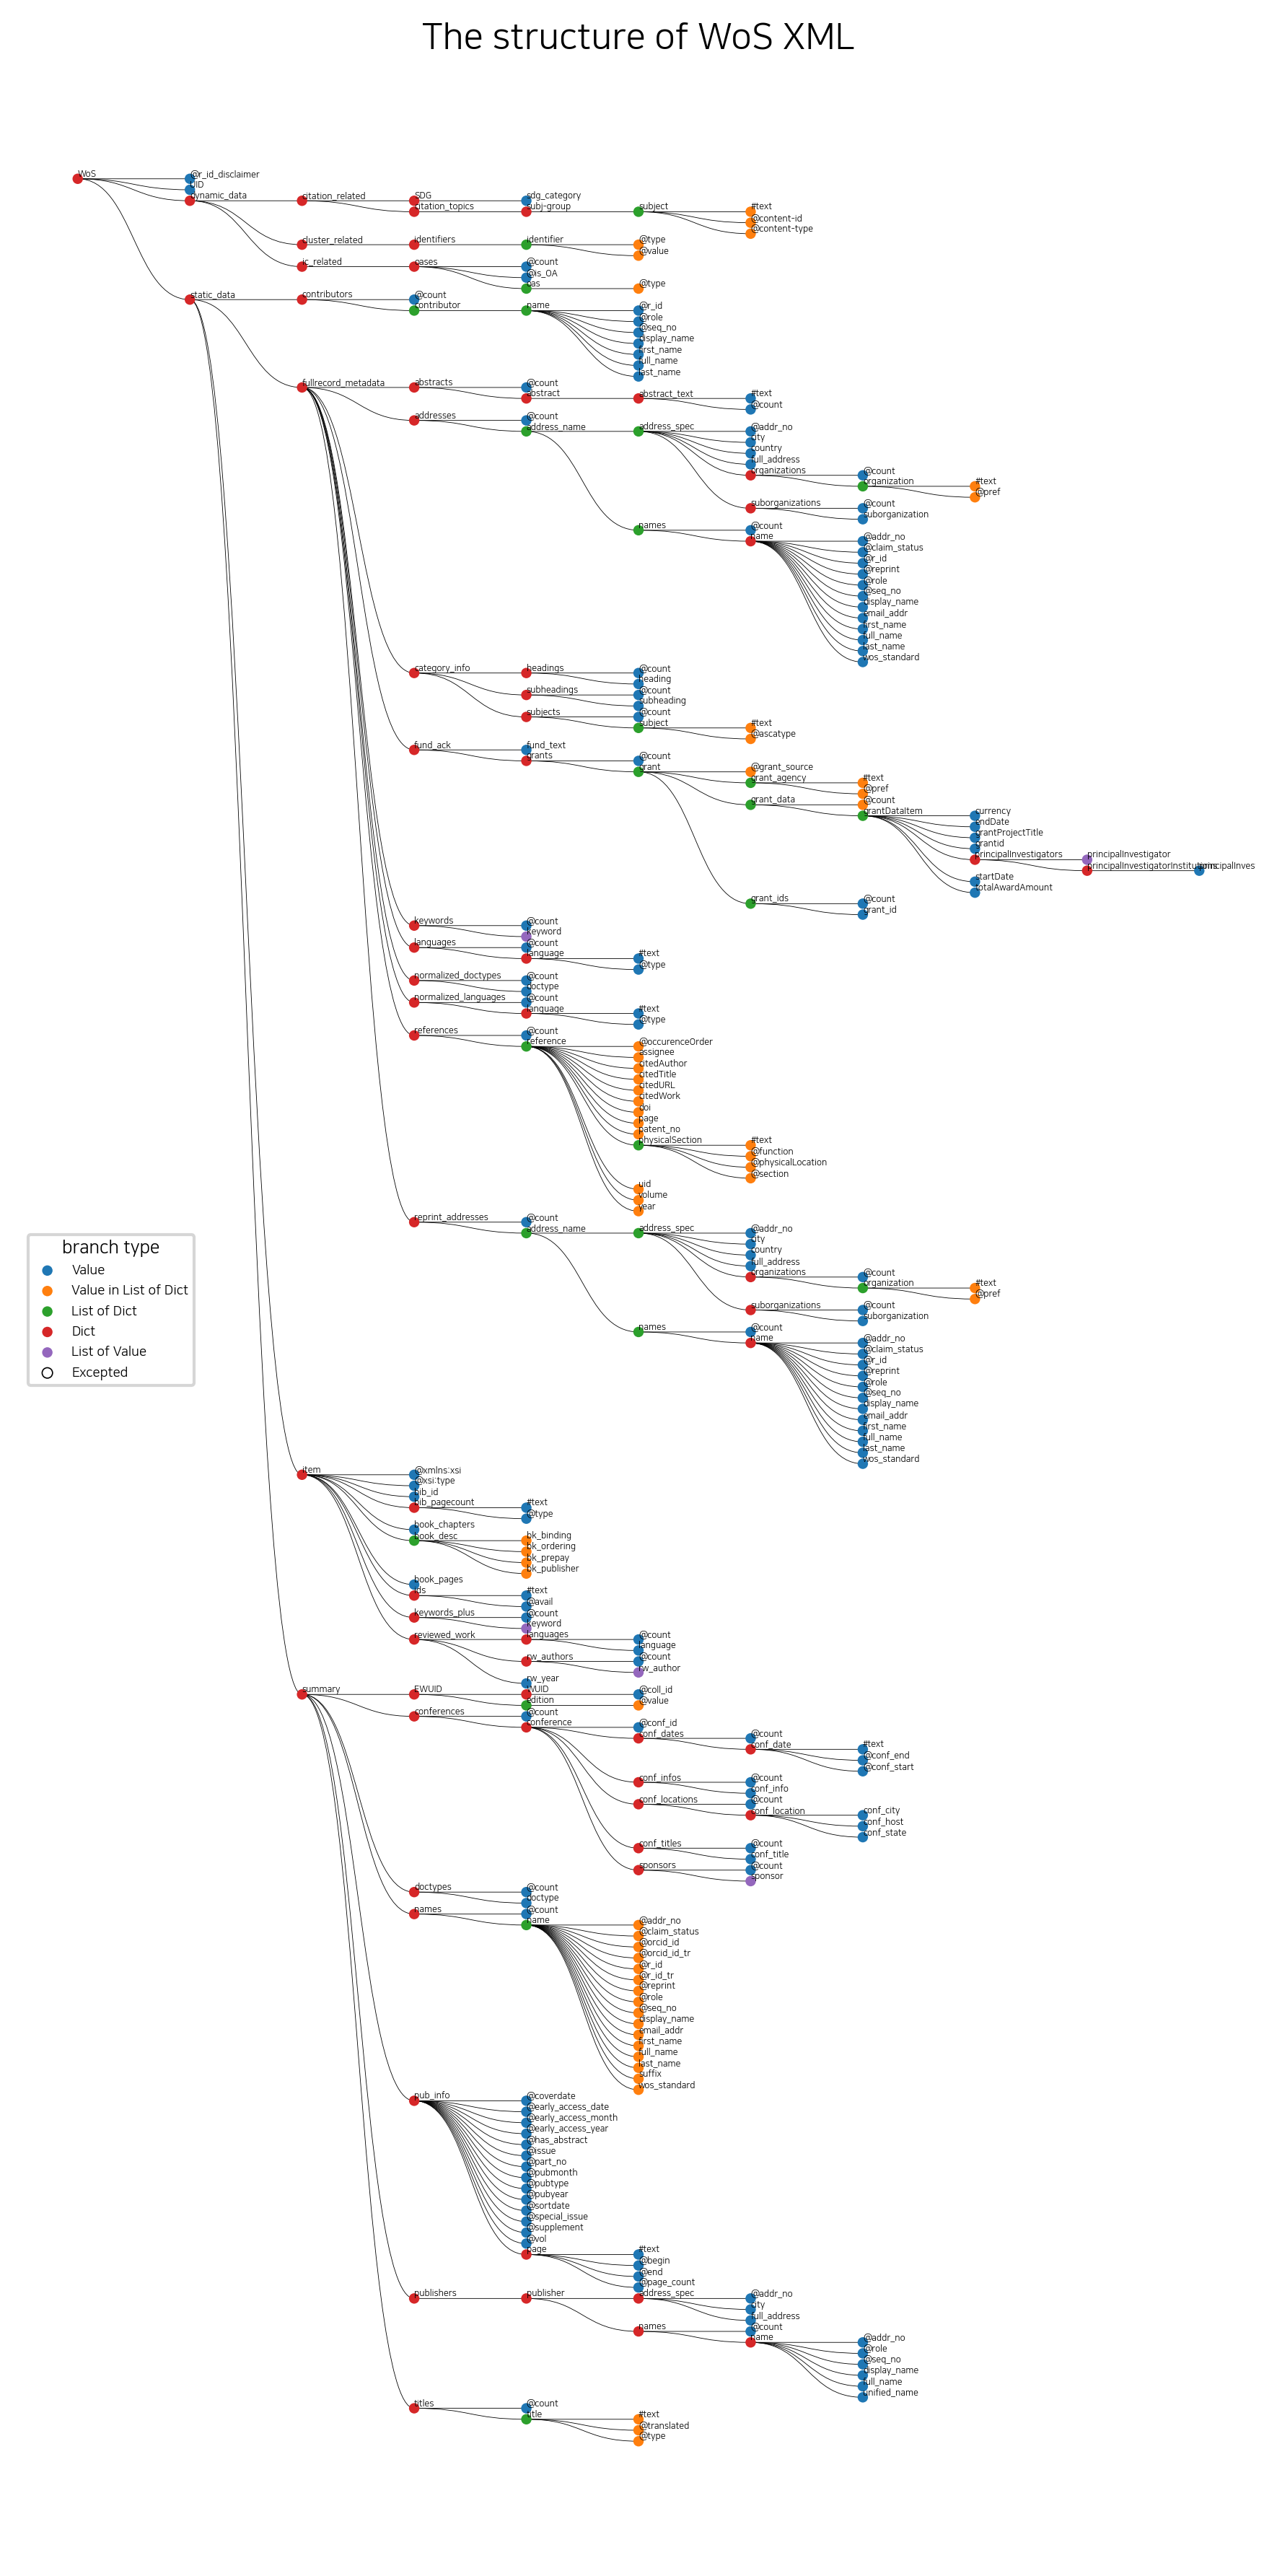

In [2452]:
except_keys = []
origin = 'WoS'
fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=12, DPI=300
                )
plt.tight_layout()
# plt.savefig("Structure_WoS_XML.svg")

In [19]:
forced = {}

key_pairs_df = processing.key_pair_to_df(key_pairs, True, forced=forced)
key_pairs_df

ValueError: cannot reindex on an axis with duplicate labels

In [203]:
jsons[0]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001037010200001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SCI'}},
   'pub_info': {'@sortdate': '2023-07-26',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': 'JUL 26 2023',
    '@pubmonth': 'JUL 26',
    '@early_access_date': 'JUL 2023',
    '@early_access_month': '07',
    '@early_access_year': '2023',
    '@pubtype': 'Journal',
    'page': {'@page_count': '9'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'MODERN PHYSICS LETTERS B'},
     {'@type': 'source_abbrev', '#text': 'MOD PHYS LETT B'},
     {'@type': 'abbrev_iso', '#text': 'Mod. Phys. Lett. B'},
     {'@type': 'abbrev_11', '#text': 'MOD PHY L B'},
     {'@type': 'abbrev_29', '#text': 'MOD PHYS LETT B'},
     {'@type': 'item',
      '#text': 'Study of propagation of skew cosh Gaussian laser beam in attenuated magneto plasma'}]},
   'name

In [ ]:
key_pairs = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(excepted_part[ekey], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

In [6]:
index_key = 'UID'
except_keys = ['dynamic_data'] # exception part for unstructured json branches

df, df_subs, excepted_part = processing.extract_data_from_jsons(jsons[:], index_key, except_keys)

  0%|                                        | 1/100000 [00:00<24:29, 68.03it/s]


KeyError: 'static_data__summary__doctypes__doctype'

In [607]:
df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__fullrecord_metadata__category_info__subjects__subject'])

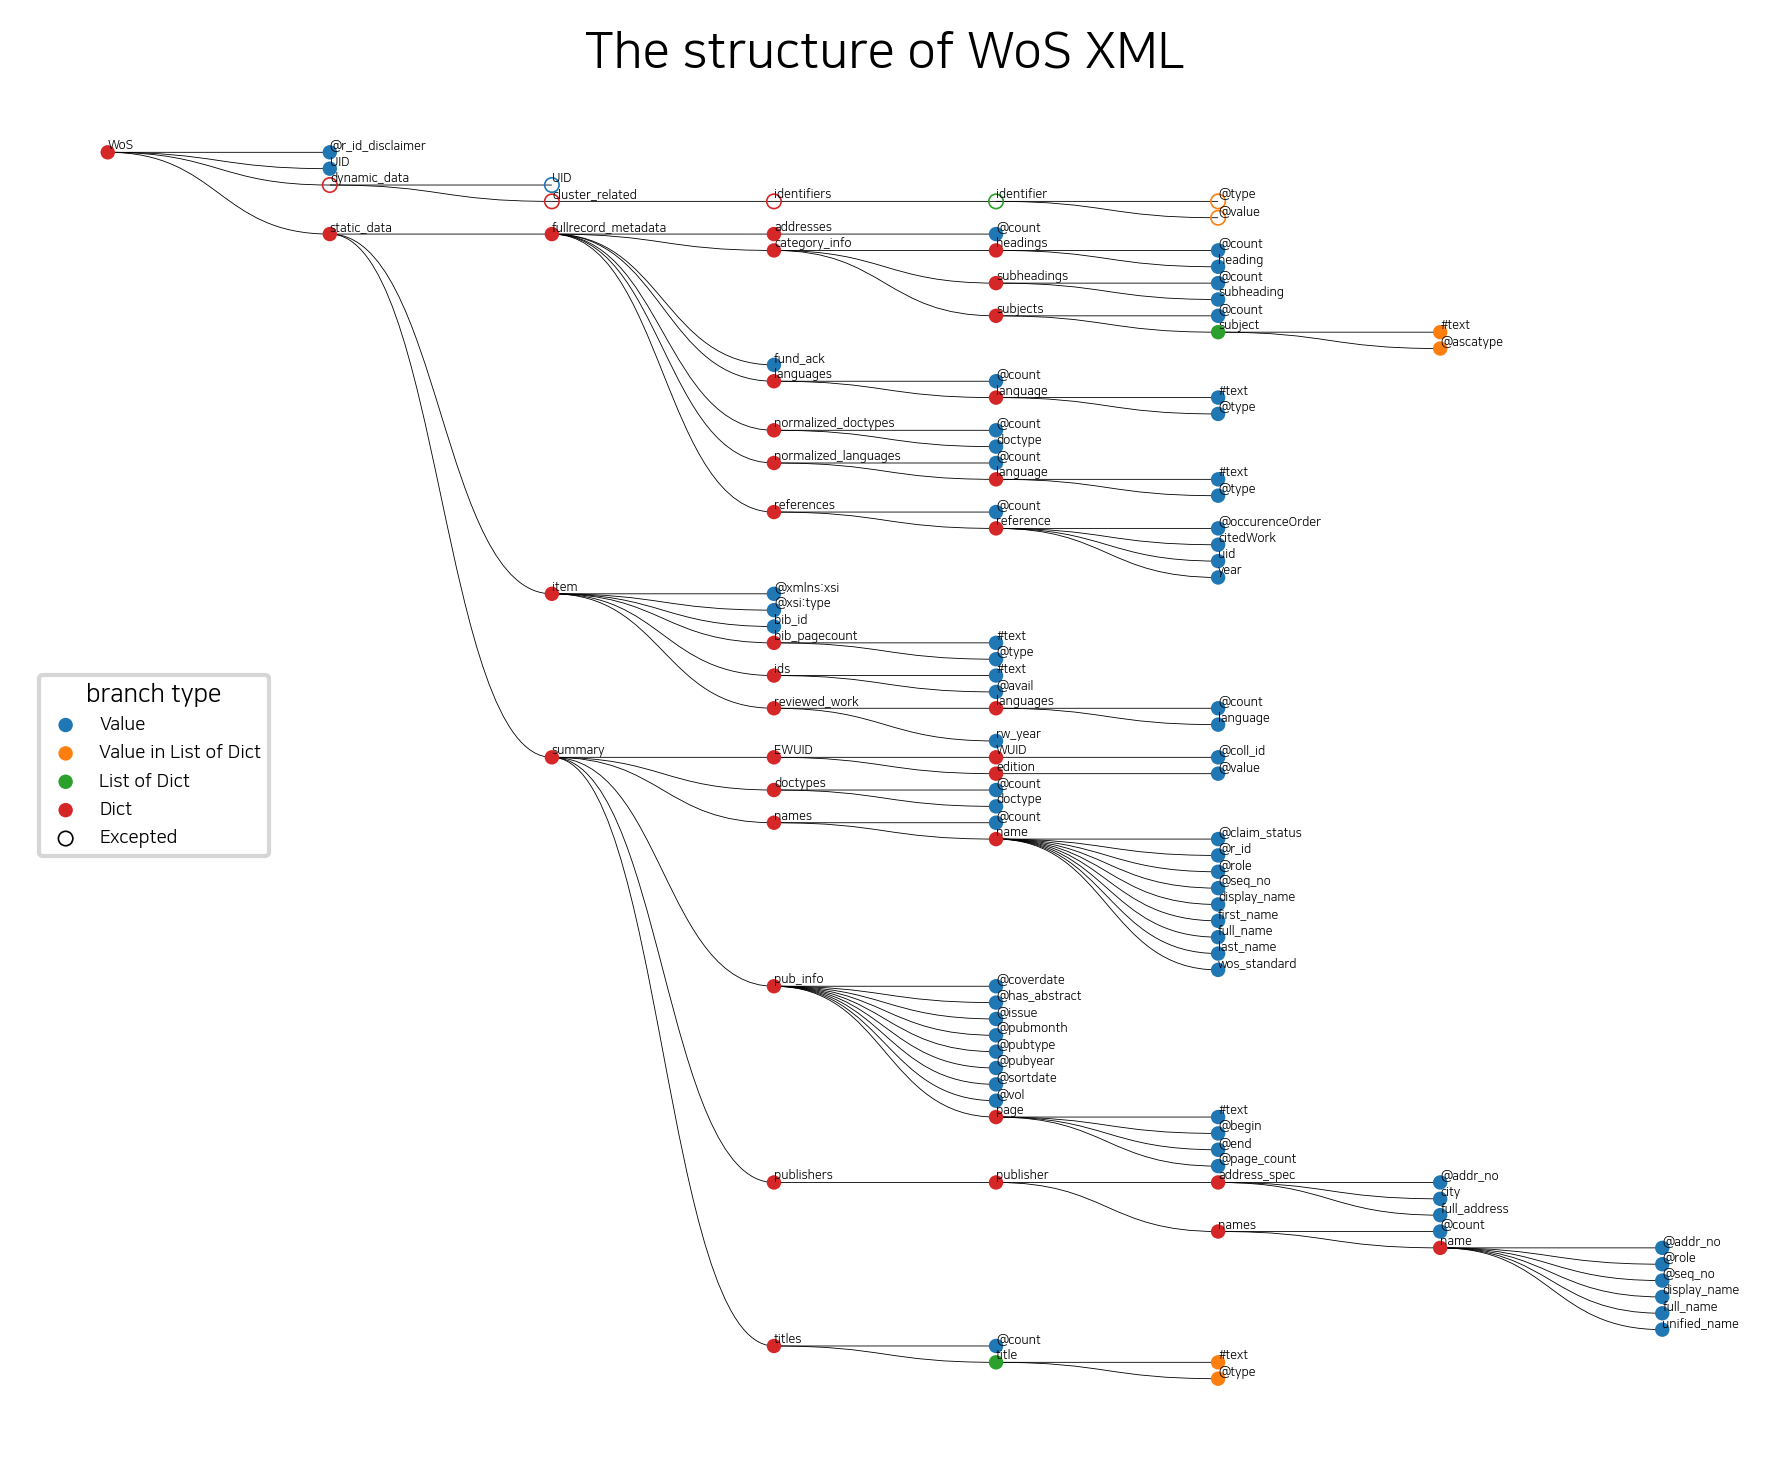

In [909]:
except_keys = ['dynamic_data']
origin = 'WoS'
fig = plot.plot_schema(jsons[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          # legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML.svg")

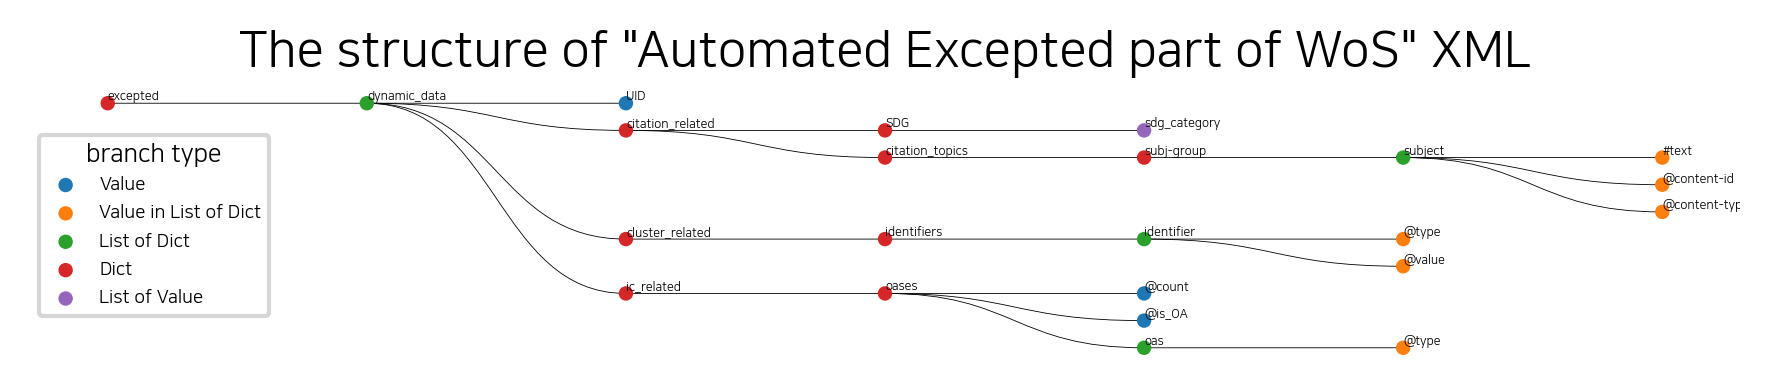

In [908]:
forced = {
    'excepted__dynamic_data__citation_related': 'Dict',
    'excepted__dynamic_data__cluster_related': 'Dict',
    'excepted__dynamic_data__ic_related': 'Dict',
    'excepted__dynamic_data__UID': 'Value',
}
data_name = '"Automated Excepted part of WoS"'
origin = 'excepted'
fig = plot.plot_schema(excepted_part, data_name=data_name, origin=origin, forced=forced,
          legend_loc='bottom left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=1.4, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML_Excepted.svg")

In [656]:
key_pairs = processing.json_to_key_pairs(excepted_part, origin)
key_pairs_df = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(excepted_part[ekey], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

100%|████████████████████████████████████| 51167/51167 [02:42<00:00, 315.35it/s]


In [833]:
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample'
}

processing.save_data([df, df_subs, df_ex, df_ex_subs], data_config)

'Data_Sample/01__WoS_Sample__MN.ftr' is successfully saved.
'Data_Sample/02__WoS_Sample__MN-SUB__static_data__summary__titles__title.ftr' is successfully saved.
'Data_Sample/03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject.ftr' is successfully saved.
'Data_Sample/04__WoS_Sample__EX.ftr' is successfully saved.
'Data_Sample/05__WoS_Sample__EX-SUB__ic_related__oases__oas.ftr' is successfully saved.
'Data_Sample/06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier.ftr' is successfully saved.
'Data_Sample/07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category.ftr' is successfully saved.
'Data_Sample/08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject.ftr' is successfully saved.


In [834]:
# From here, the SEP means separation for the tabular file like 'csv'
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample',
    'Conv_DATETIME': False,
}

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

PATH = data_config['PATH']
flist = sorted([x for x in os.listdir(PATH) if '.ftr' in x])
df_descs = []
for f in flist:
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    df_descs.append(df_desc)

Generate the Description file for table `01__WoS_Sample__MN`
Generate the Description file for table `02__WoS_Sample__MN-SUB__static_data__summary__titles__title`
Generate the Description file for table `03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject`
Generate the Description file for table `04__WoS_Sample__EX`
Generate the Description file for table `05__WoS_Sample__EX-SUB__ic_related__oases__oas`
Generate the Description file for table `06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier`
Generate the Description file for table `07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category`
Generate the Description file for table `08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject`


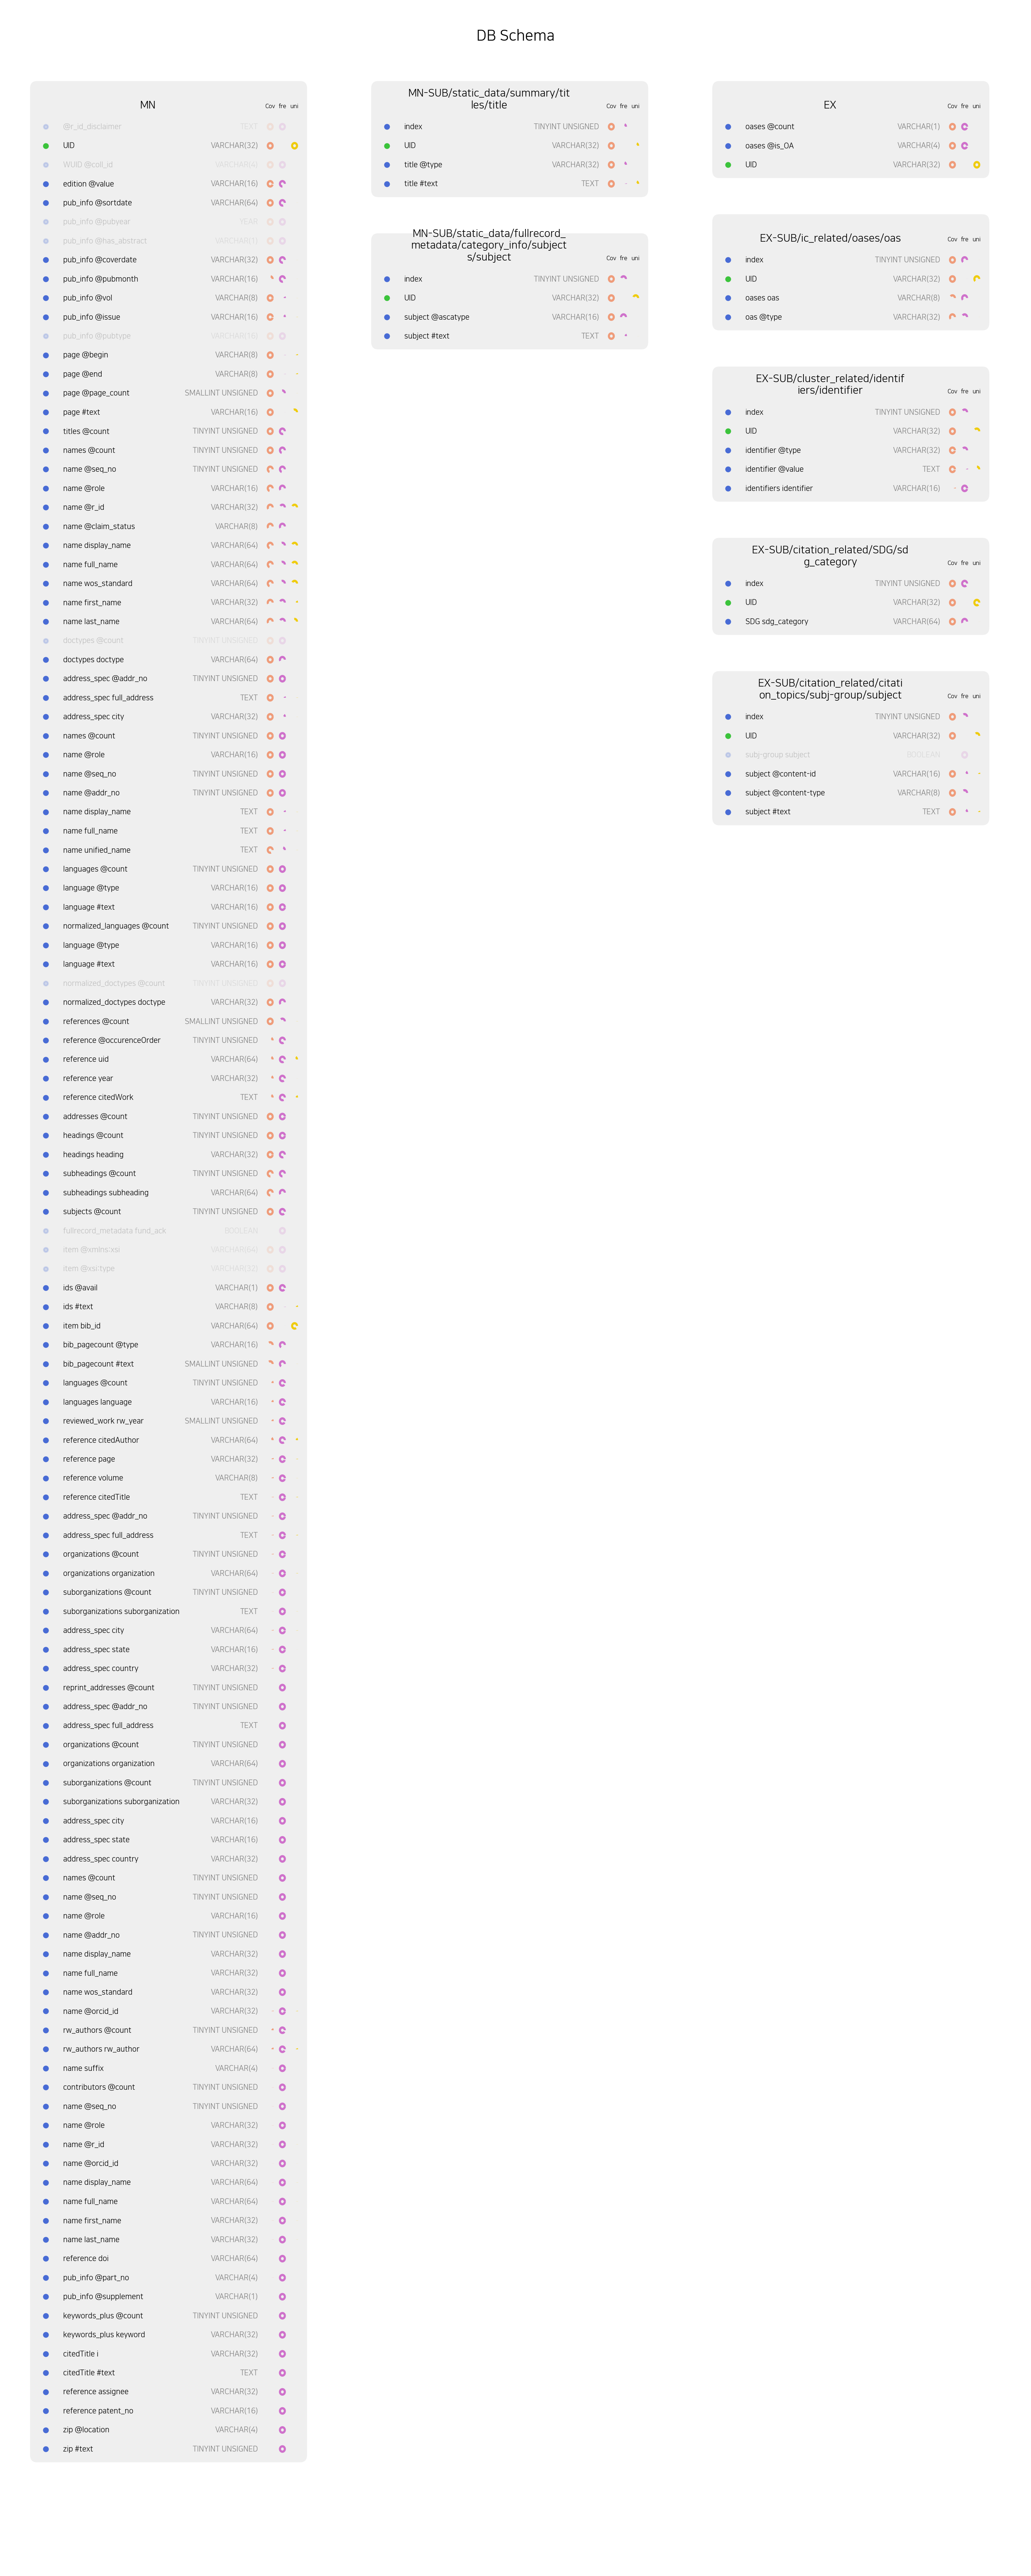

In [918]:
# legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
node_size=8
font_size=5
X_SIZE=10
Y_SIZE=24
DPI=300

title='DB Schema'
sep='__'
x_unit=1
table_unit = x_unit*14
features = ['Coverage', 'freq', 'uniq_ratio']

# plt.rcParams['svg.fonttype'] = 'path'
svg_fonttype = 'none'
#svg.fonttype : 'path'         # How to handle SVG fonts:
#    'none': Assume fonts are installed on the machine where the SVG will be viewed.
#    'path': Embed characters as paths -- supported by most SVG renderers
#    'svgfont': Embed characters as SVG fonts -- supported only by Chrome,
#               Opera and Safarids



draw_schema()
plt.savefig("test.svg")

In [917]:
def draw_schema(node_size=8, font_size=5, X_SIZE=10, Y_SIZE=24, title='DB Schema', x_unit=1, table_unit=14, features=['Coverage', 'freq', 'uniq_ratio'], DPI=300, svg_fonttype='none', sep='__'):
    import matplotlib.patches as mpatches
    from matplotlib.patches import Wedge
    
    def write_item():
        x = x_base
        y = y_base-i
        # name = idx.split(sep)[-1]
        
        name = " ".join(idx.split(sep)[-2:])
        type = df_desc.loc[idx, 'Type']
        fts = df_desc.loc[idx, features]
        freq = df_desc.loc[idx, 'freq']
        colors = ['lightsalmon', 'orchid', 'gold']
        color = 'royalblue'
        if freq == 1.: # freq
            alpha = 0.2
        else:
            alpha = 1.
            
        if name == index_key:
            color = 'limegreen'
        
        plt.scatter(x, y, alpha=alpha, s=node_size, c=color)
        plt.text(x+x_unit, y, name, alpha=alpha, ha='left', va='center', fontdict=dict(fontsize=font_size)) # Name
        plt.text(x+x_unit+table_unit*.8, y, type, alpha=alpha, ha='right', va='center', color='grey', fontdict=dict(fontsize=font_size)) # Type
        # Coverage, freq, uniq_ratio
        for j, v in enumerate(fts):
            _wedge = mpatches.Wedge((x+x_unit+table_unit*(.85 + 0.05*j), y), 0.2, 0, 360*v, alpha=alpha, width=0.12, ec="none", fc=colors[j])
            ax.add_artist(_wedge)
    
    
    def split_title_line(title_text, max_words=24):  # , max_words=None):
        """
        A function that splits any string based on specific character
        (returning it with the string), with maximum number of words on it
        """
        splited = []
        text = title_text[:]
        while text != '':
            splited.append(text[:max_words])
            text = text[max_words:]
        return '\n'.join(splited)
    
    
    def base_set(x_base, y_base, fi, max_words):
        f = flist[fi]
        table_name = "/".join(f.split('/')[-1].split(sep)[2:])[:-4]
        table_name = split_title_line(table_name, max_words=max_words)
        
        if (table_name == 'EX') | (fi == 1):
            x_base += table_unit*1.4
            y_base = 0
        elif fi != 0:
            y_base -= i+5
        plt.text(x_base+table_unit*.42, y_base+1, table_name, ha='center', fontdict=dict(fontsize=font_size*1.4))
        for j, v in enumerate(features):
            plt.text(x_base+x_unit+table_unit*(.85 + 0.05*j), y_base+1, v[:3], ha='center', fontdict=dict(fontsize=font_size*.8))
        return x_base, y_base
    
    
    def set_bbox():
        box = mpatches.FancyBboxPatch((x_base-x_unit*.5, y_base-i-.3), table_unit*1.08, i+2.3, ec="none", fc='grey', alpha=.12,
                                boxstyle=mpatches.BoxStyle("Round", pad=.4))
        ax.add_artist(box)
    
    
    N_ROW = 1
    N_COL = 1
    plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
    plt.rcParams['svg.fonttype'] = svg_fonttype
    
    fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
    spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig, )#, width_ratios=[1,1,.1], wspace=.3)
    axes = []
    axi=0
    ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col
    
    ########### Draw ###########
    x_base, y_base = 0, 0
    patches = []
    for fi, df_desc in enumerate(df_descs):
        x_base, y_base = base_set(x_base, y_base, fi, max_words=30)
        for i, idx in enumerate(df_desc.index):
            write_item() ## a line
        set_bbox()
    
    plt.xlim([-x_unit*2, table_unit*4])
    
    plt.tight_layout()
    plt.axis('off')
    plt.title(title, y=0.985, fontdict=dict(fontsize=font_size*2))
    
    return fig

# Excepted branch

## Consider Excepted part
- accumulate the date
    - single > multiple
    - couverage checing
    - coloring
    - optimizion

In [ ]:
data_config = {
    'PATH': 'Data_Sample/',
    'SEP': ',',
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [20]:
PATH = '../Data/Funding/KR_NTIS/'
SEP = '\t'
Port = 0 # Port for DB with host
CHARACTER_SET = 'utf8mb4'
COLLATE = 'utf8mb4_unicode_520_ci'

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

db_config = {
    'host': 'localhost',  # Update as needed
    'user': 'user',       # Update as needed
    'password': '1234',       # Update as needed
    'database': 'KR_NTIS_2023_raw'  # Update as needed
}

data_config = {
    'PATH': PATH,
    'SEP': SEP,
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [ ]:
manage.init_MySQL()
try:
    manage.drop_DB(db_config['database'], db_config)
except:
    pass
manage.create_DB(db_config['database'], CHARACTER_SET, COLLATE, db_config)


# Generate the Tabular File list
flist = sorted([x for x in os.listdir(PATH) if 'raw.ftr' in x])
for f in tqdm(flist[:]):
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    
    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

 * Starting MySQL database server mysqld
   ...done.
Failed to drop database `KR_NTIS_2023_raw`. Error: (1049, "Unknown database 'KR_NTIS_2023_raw'")
Database `KR_NTIS_2023_raw` created successfully.


  0%|                                                    | 0/16 [00:00<?, ?it/s]

Generate the Description file for table `1_Projects_raw`
Table `1_Projects_raw` created successfully.
Data inserted into table `1_Projects_raw` successfully.
Set Index the 과제고유번호 on `1_Projects_raw` successfully.


In [ ]:
manage.backup_database_subprocess(db_config, data_config)

In [81]:
_df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__summary__names__name', 'static_data__fullrecord_metadata__references__reference', 'static_data__fullrecord_metadata__category_info__subjects__subject', 'dynamic_data__citation_related__citation_topics__subj-group__subject'])